# Model identifiability and posterior predictive checks

The confusion matrices assess whether data generated by each clean RDM model are assigned back to that model. The posterior predictive checks assess whether each assumed model can reproduce condition-specific accuracy and reaction-time distributions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "benchmark").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Could not locate the benchmark package.")
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.config import FIGURE_DIR, TrainingConfig
from benchmark.examples.diffusion.results.model_checks import (
    PPC_PATH,
    compute_or_load_ppc,
    compute_or_load_ppc_density_overlay,
    compute_or_load_npe_ppc,
    confusion_matrices,
    plot_empirical_ppc,
    plot_empirical_pmp_error_boxplots,
    plot_matrix_grid,
    plot_ppc_misfit_heatmap,
    ppc_misfit_summary,
    save_ppc_density_overlay_figures,
)
from benchmark.examples.diffusion.results.multisource_pipeline import load_cached_all_observed

PLOT_DIR = FIGURE_DIR / "model_checks"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CONFIGS = {
    "S=D": TrainingConfig(summary_multiplier=1),
    "S=2D": TrainingConfig(summary_multiplier=2),
    "S=4D": TrainingConfig(summary_multiplier=4),
    "S=6D": TrainingConfig(summary_multiplier=6),
}
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11})

Matplotlib is building the font cache; this may take a moment.
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


## Confusion matrices

Rows are data-generating models and columns are selected models. Only the clean `simulated_from_m0` to `simulated_from_m3` datasets are used.

In [2]:
results_by_summary = {
    label: load_cached_all_observed(config)["results"]
    for label, config in SUMMARY_CONFIGS.items()
}
hard_confusion, mean_pmp = confusion_matrices(results_by_summary)

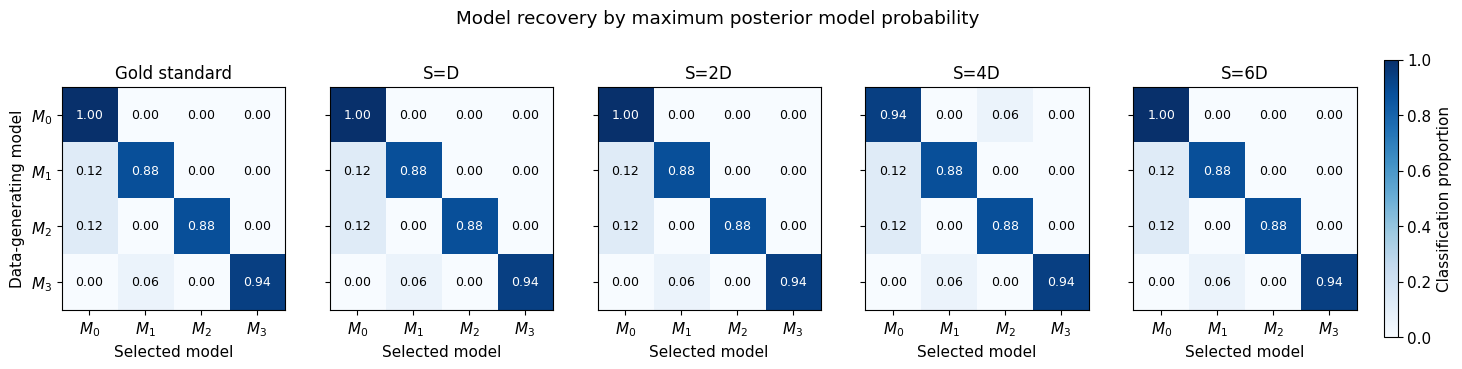

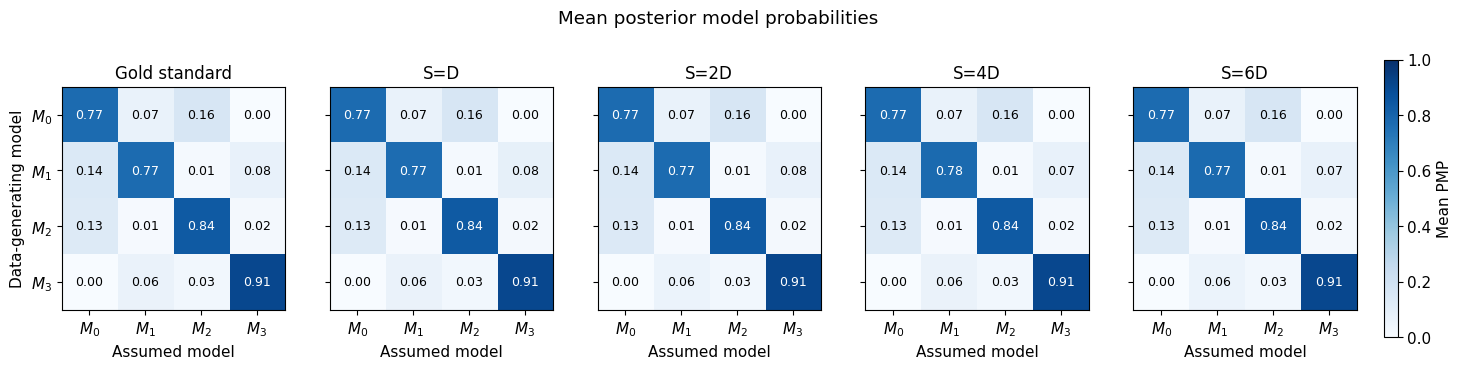

In [3]:
fig_hard, axes_hard = plot_matrix_grid(
    hard_confusion,
    title="Model recovery by maximum posterior model probability",
    colorbar_label="Classification proportion",
    filename=PLOT_DIR / "model_confusion_matrix.png",
)
plt.show()

fig_mean, axes_mean = plot_matrix_grid(
    mean_pmp,
    title="Mean posterior model probabilities",
    colorbar_label="Mean PMP",
    filename=PLOT_DIR / "mean_pmp_matrix.png",
)
plt.show()

## Empirical PMP error across summary dimensions

Each panel corresponds to one assumed model in the full four-model comparison. Each box contains the signed PMP errors of the 17 empirical participants.

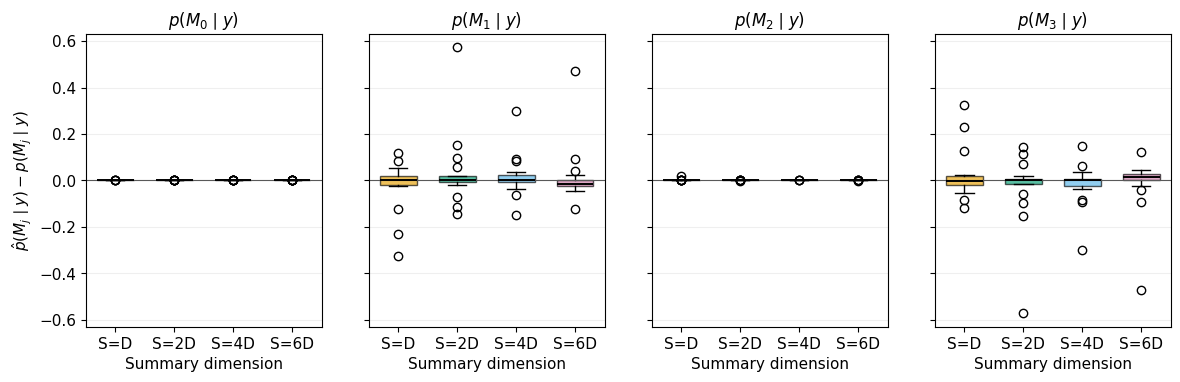

In [4]:
fig_pmp_box, axes_pmp_box = plot_empirical_pmp_error_boxplots(
    results_by_summary,
    filename=PLOT_DIR / "empirical_pmp_error_by_summary_dimension.png",
)
plt.show()

## Stan posterior predictive checks

The first run simulates replicated datasets from the existing Stan posterior draws and saves the checks to `results/posterior_predictive_checks/stan_ppc.csv`. Later runs load this cache. Set `RECOMPUTE = True` only when the observed datasets or posterior draws change; cache settings are checked automatically.

`c0` is the accuracy condition and `c1` is the speed condition. Positive RT denotes a correct response and negative RT denotes an error.

In [5]:
RECOMPUTE = False
ppc = compute_or_load_ppc(
    num_draws=256,
    interval=0.90,
    seed=2025,
    recompute=RECOMPUTE,
)
print(f"PPC cache: {PPC_PATH}")
print(f"Rows: {len(ppc):,}")
ppc.head()

PPC cache: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/posterior_predictive_checks/stan_ppc.csv
Rows: 7,580


,dataset,id,model,statistic,observed,predictive_lower,predictive_median,predictive_upper,predictive_percentile,outside_interval,num_predictive_draws,requested_num_draws,interval
0,empirical,p0,m0,accuracy_c0,0.901042,0.843750,0.890625,0.937500,0.664062,False,256,256,0.9
1,empirical,p0,m0,rt_q10_c0_correct,0.470000,0.449174,0.554718,0.757342,0.125000,False,256,256,0.9
2,empirical,p0,m0,rt_q50_c0_correct,0.578000,0.584145,0.691287,0.896517,0.039062,True,256,256,0.9
3,empirical,p0,m0,rt_q90_c0_correct,0.811200,0.814945,0.931901,1.134091,0.050781,True,256,256,0.9
4,empirical,p0,m0,rt_q10_c0_error,0.469000,0.453726,0.593154,0.769435,0.078125,False,256,256,0.9


In [6]:
ppc_summary = ppc_misfit_summary(ppc)
ppc_summary.pivot(index="dataset", columns="model", values="outside_rate").round(3)

model,m0,m1,m2,m3
dataset,,,,
empirical,0.529,0.336,0.508,0.290
m3_fast_30,0.592,0.471,0.475,0.151
m3_fast_slow_30,0.732,0.553,0.574,0.336
m3_slow_30,0.773,0.592,0.655,0.324
simulated_from_m0,0.034,0.021,0.017,0.000
simulated_from_m1,0.445,0.025,0.395,0.008
simulated_from_m2,0.500,0.492,0.021,0.017
simulated_from_m3,0.789,0.466,0.664,0.026


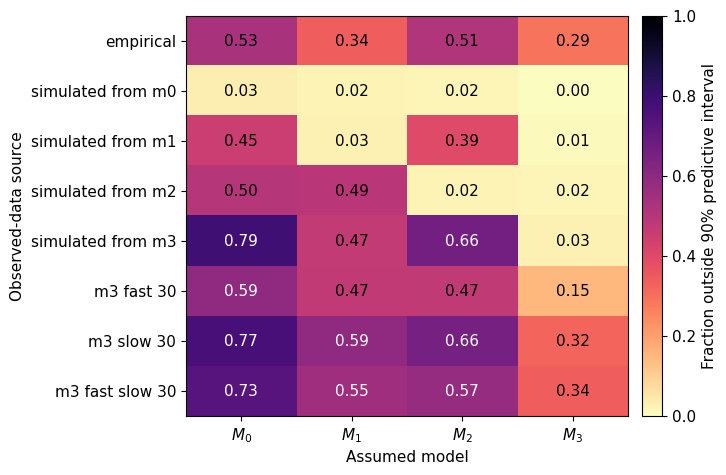

In [7]:
fig_ppc, ax_ppc = plot_ppc_misfit_heatmap(
    ppc,
    filename=PLOT_DIR / "stan_ppc_misfit_by_source.png",
)
plt.show()



## NPE posterior predictive checks

This repeats the Stan heatmap using replicated datasets generated from NPE posterior samples. Change `NPE_SUMMARY` to select another trained summary dimension.

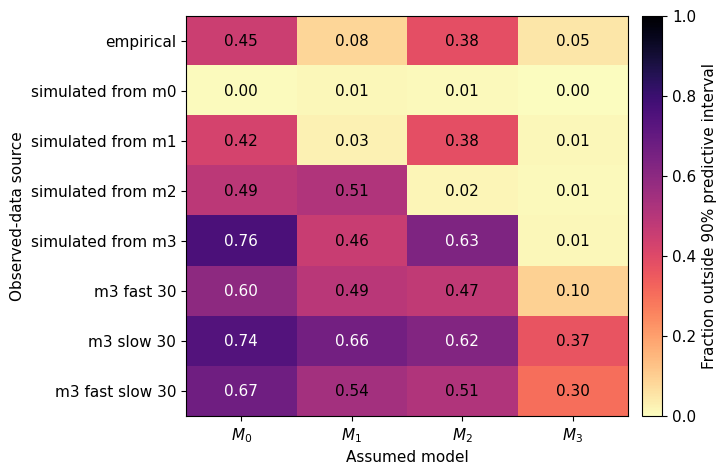

In [8]:
NPE_SUMMARY = "S=D"
npe_config = SUMMARY_CONFIGS[NPE_SUMMARY]

npe_ppc = compute_or_load_npe_ppc(
    config=npe_config,
    num_draws=256,
    interval=0.90,
    batch_size=8,
    seed=2025,
    recompute=False,
)

fig_npe_ppc, ax_npe_ppc = plot_ppc_misfit_heatmap(
    npe_ppc,
    filename=PLOT_DIR / f"npe_ppc_misfit_by_source_{npe_config.summary_label}.png",
)
plt.show()

## NPE posterior predictive density overlay

The dark curve is the pooled empirical signed-RT distribution. Each light curve is one complete NPE posterior predictive replication pooled over the 17 participants. Negative RT denotes an error and positive RT denotes a correct response.

In [9]:
# Response coding verified in dataset/dataset.py:
# signed RT > 0 means stim_cat == response (correct); signed RT < 0 means incorrect.
# Condition 0 is accuracy and condition 1 is speed. Positive/negative RTs are fitted jointly.
PPC_OVERLAY_SOURCE = "npe"  # "stan" or "npe"
overlay_config = None if PPC_OVERLAY_SOURCE == "stan" else npe_config
overlay_label = "stan" if overlay_config is None else f"npe_{overlay_config.summary_label}"

ppc_overlay = compute_or_load_ppc_density_overlay(
    source=PPC_OVERLAY_SOURCE,
    config=overlay_config,
    dataset="empirical",
    num_replicates=80,
    batch_size=8,
    seed=2025,
    recompute=False,
)

overlay_paths, overlay_skip_diagnostics = save_ppc_density_overlay_figures(
    ppc_overlay,
    output_dir=PLOT_DIR / f"{overlay_label}_signed_rt_ppc",
    include_envelope=True,
)
overlay_skip_diagnostics

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

,dataset,id,source,summary,condition,model,requested_replicates,valid_replicates,skipped_replicates
0,empirical,p0,npe,S1D,0,m0,80,80,0
1,empirical,p0,npe,S1D,0,m1,80,80,0
2,empirical,p0,npe,S1D,0,m2,80,80,0
3,empirical,p0,npe,S1D,0,m3,80,80,0
4,empirical,p0,npe,S1D,1,m0,80,80,0
...,...,...,...,...,...,...,...,...,...
199,empirical,p9,npe,S1D,1,m3,80,80,0
200,empirical,p9,npe,S1D,pooled,m0,80,80,0
201,empirical,p9,npe,S1D,pooled,m1,80,80,0
202,empirical,p9,npe,S1D,pooled,m2,80,80,0


In [10]:
PPC_OVERLAY_SOURCE = "stan"  # "stan" or "npe"
overlay_config = None if PPC_OVERLAY_SOURCE == "stan" else npe_config
overlay_label = "stan" if overlay_config is None else f"npe_{overlay_config.summary_label}"

ppc_overlay = compute_or_load_ppc_density_overlay(
    source=PPC_OVERLAY_SOURCE,
    config=overlay_config,
    dataset="empirical",
    num_replicates=80,
    batch_size=8,
    seed=2025,
    recompute=False,
)

overlay_paths, overlay_skip_diagnostics = save_ppc_density_overlay_figures(
    ppc_overlay,
    output_dir=PLOT_DIR / f"{overlay_label}_signed_rt_ppc",
    include_envelope=True,
)
overlay_skip_diagnostics

,dataset,id,source,summary,condition,model,requested_replicates,valid_replicates,skipped_replicates
0,empirical,p0,stan,,0,m0,80,80,0
1,empirical,p0,stan,,0,m1,80,80,0
2,empirical,p0,stan,,0,m2,80,80,0
3,empirical,p0,stan,,0,m3,80,80,0
4,empirical,p0,stan,,1,m0,80,80,0
...,...,...,...,...,...,...,...,...,...
199,empirical,p9,stan,,1,m3,80,80,0
200,empirical,p9,stan,,pooled,m0,80,80,0
201,empirical,p9,stan,,pooled,m1,80,80,0
202,empirical,p9,stan,,pooled,m2,80,80,0


### Interpretation

- A diagonal hard-confusion matrix indicates recoverable model identities; off-diagonal mass identifies systematic model confusion.
- The mean-PMP matrix retains uncertainty that is hidden by the argmax decision.
- The nominal reference for a 90% interval is 0.10, although posterior predictive checks can be conservative because the observed data are also used to fit the posterior. Use the clean simulated diagonal cells as the empirical baseline.
- Outside rates substantially above that baseline indicate that the assumed model fails to reproduce the selected behavioral statistics.
- Compare clean and contaminated sources to distinguish structural model overlap from deliberate out-of-distribution misspecification.